<a href="https://colab.research.google.com/github/seforarosenberg25/css-therapygpt-bertopic/blob/main/Ganzer_TherapieGPT_vergleich_Flairs_bertopic_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BERTopic — with BERT Embeddings
**Corpus:** **Corpus:** r/TherapyGPT — Ganzer Reddit vergleich

**Embedding model:** `sentence-transformers/all-mpnet-base-v2`

### What this notebook does
1. Load corpus
2. Embed documents with MPNet (contextual, not bag of words)
3. Reduce dimensions with UMAP
4. Cluster with HDBSCAN — K emerges from the data
5. Represent topics with c-TF-IDF
6. Inspect and visualise results

## 0. Imports and setup

In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.4 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from google.colab import drive

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

import matplotlib.pyplot as plt
import matplotlib as mpl

# Mount Google Drive
drive.mount('/content/drive/')

# ── Angepasst auf euren TherapyGPT-Korpus ────────────────────────────
DATA_PATH = Path('/content/drive/MyDrive/crypto_corpus/reddit_therapygpt_paragraphs.parquet')
if not DATA_PATH.exists():
    DATA_PATH = DATA_PATH.with_suffix('.csv')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'Data   : {DATA_PATH}')

Mounted at /content/drive/
Device : cuda
Data   : /content/drive/MyDrive/crypto_corpus/reddit_therapygpt_paragraphs.csv


## 1. Load corpus

In [ ]:
from pathlib import Path

# Correcting DATA_PATH as it seems to be defined incorrectly in the previous cell
# The files are directly under MyDrive, not in a 'crypto_corpus' subfolder.
DATA_PATH = Path('/content/drive/MyDrive/reddit_therapygpt_paragraphs.parquet')
if not DATA_PATH.exists():
    DATA_PATH = DATA_PATH.with_suffix('.csv')

df = (pd.read_parquet(DATA_PATH) if DATA_PATH.suffix == '.parquet'
      else pd.read_csv(DATA_PATH, parse_dates=['created_utc']))

print(f'Absätze : {len(df):,}')
print(df.groupby('subreddit')['post_id'].count().to_string())

docs = df['paragraph_text'].tolist()

Absätze : 6,524
subreddit
TherapyGPT    6524


## 2. Embedding model — `sentence-transformers/all-mpnet-base-v2`
`all-mpnet-base-v2` provides the best quality for general-purpose semantic similarity tasks in the `sentence-transformers` library while remaining efficient enough for standard GPU runtimes.

In [ ]:
EMBEDDING_MODEL = 'sentence-transformers/all-mpnet-base-v2'

print(f'Loading {EMBEDDING_MODEL}...')
embedding_model = SentenceTransformer(
    EMBEDDING_MODEL,
    trust_remote_code=False,
    device=DEVICE,
)
print(f'Embedding dim : {embedding_model.get_sentence_embedding_dimension()}')

Loading sentence-transformers/all-mpnet-base-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dim : 768


## 3. Pre-compute embeddings
We do this once and pass them to BERTopic — avoids re-embedding if you
experiment with different UMAP / HDBSCAN settings.

In [ ]:
import torch

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache cleared before embedding.")

# Create output directory if it doesn't exist to avoid FileNotFoundError
OUT_DIR = Path('./therapygpt_output')
OUT_DIR.mkdir(exist_ok=True)

print(f'Embedding {len(docs):,} documents...')
embeddings = embedding_model.encode(
    docs,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
)
print(f'Embeddings shape: {embeddings.shape}')

EMBED_PATH = OUT_DIR / 'all_mpnet_embeddings.npy'
np.save(EMBED_PATH, embeddings)
print(f'Saved → {EMBED_PATH}')

CUDA cache cleared before embedding.
Embedding 6,524 documents...


Batches:   0%|          | 0/204 [00:00<?, ?it/s]

Embeddings shape: (6524, 768)
Saved → therapygpt_output/all_mpnet_embeddings.npy


In [ ]:
# To reload cached embeddings on subsequent runs:
# embeddings = np.load(EMBED_PATH)

## 4. Configure pipeline components
Each stage has its own hyperparameters.
**Fix all random seeds** — BERTopic has three stochastic stages.

In [ ]:
# ── UMAP & HDBSCAN für den GESAMTEN Korpus (alle Flairs) ─────────────────────
umap_model_full = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42,
    low_memory=True,
)

hdbscan_model_full = HDBSCAN(
    min_cluster_size=50,   # größerer Wert, da wir wieder 6.524 statt 565 Absätze haben
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
)

STOP_EXTRA = [
    'reddit', 'post', 'comment', 'thread', 'edit', 'update',
    'would', 'could', 'also', 'one', 'get', 'got', 'like',
    'know', 'think', 'people', 'thing', 'way', 'just', 'really',
    'ai', 'therapy', 'therapist', 'therapists', 'therapies',
    'chatgpt', 'gpt', 'gemini', 'claude', 'openai', 'anthropic', 'pro',
    'don', 'didn', 've', 're', 'll', 'ain', 'isn', 'wasn', 'doesn', 'couldn', 'wouldn', 'shouldn',
]
cv_full = CountVectorizer(stop_words='english', ngram_range=(1, 2))
from sklearn.feature_extraction import text as sk_text
sk_text.ENGLISH_STOP_WORDS = frozenset(list(sk_text.ENGLISH_STOP_WORDS) + STOP_EXTRA)

topic_model_full = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model_full,
    hdbscan_model=hdbscan_model_full,
    vectorizer_model=cv_full,
    nr_topics='auto',
    calculate_probabilities=True,
    verbose=True,
)

print('Fitting BERTopic auf dem gesamten Korpus...')
topics_full, probs_full = topic_model_full.fit_transform(docs, embeddings=embeddings)

print(f'\nTopics found : {len(set(topics_full)) - 1}')
print(f'Noise docs   : {sum(t == -1 for t in topics_full):,} '
      f'({sum(t == -1 for t in topics_full) / len(topics_full):.1%} of corpus)')

2026-07-15 10:21:11,063 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic auf dem gesamten Korpus...


2026-07-15 10:21:49,180 - BERTopic - Dimensionality - Completed ✓
2026-07-15 10:21:49,183 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-15 10:21:50,041 - BERTopic - Cluster - Completed ✓
2026-07-15 10:21:50,042 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-07-15 10:21:51,435 - BERTopic - Representation - Completed ✓
2026-07-15 10:21:51,439 - BERTopic - Topic reduction - Reducing number of topics
2026-07-15 10:21:51,452 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-15 10:21:52,886 - BERTopic - Representation - Completed ✓
2026-07-15 10:21:52,890 - BERTopic - Topic reduction - Reduced number of topics from 7 to 7



Topics found : 6
Noise docs   : 1,851 (28.4% of corpus)


## 5. Fit BERTopic
We pass the pre-computed embeddings so the model skips the embedding step.

In [ ]:
topic_model_full = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model_full,
    hdbscan_model=hdbscan_model_full,
    vectorizer_model=cv_full,
    nr_topics='auto',
    calculate_probabilities=True,
    verbose=True,
)

print('Fitting BERTopic auf dem gesamten Korpus...')
topics_full, probs_full = topic_model_full.fit_transform(docs, embeddings=embeddings)

print(f'\nTopics found : {len(set(topics_full)) - 1}  (excluding noise cluster −1)')
print(f'Noise docs   : {sum(t == -1 for t in topics_full):,}  '
      f'({sum(t == -1 for t in topics_full) / len(topics_full):.1%} of corpus)')

2026-07-15 10:21:53,376 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic auf dem gesamten Korpus...


2026-07-15 10:22:08,729 - BERTopic - Dimensionality - Completed ✓
2026-07-15 10:22:08,730 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-15 10:22:09,251 - BERTopic - Cluster - Completed ✓
2026-07-15 10:22:09,252 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-07-15 10:22:09,942 - BERTopic - Representation - Completed ✓
2026-07-15 10:22:09,945 - BERTopic - Topic reduction - Reducing number of topics
2026-07-15 10:22:09,958 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-15 10:22:10,630 - BERTopic - Representation - Completed ✓
2026-07-15 10:22:10,633 - BERTopic - Topic reduction - Reduced number of topics from 7 to 7



Topics found : 6  (excluding noise cluster −1)
Noise docs   : 1,851  (28.4% of corpus)


## 6. Topic overview

In [ ]:
info_full = topic_model_full.get_topic_info()
print(info_full[info_full['Topic'] != -1].to_string(index=False))
info_full.to_csv(OUT_DIR / 'bertopic_topic_info_full.csv', index=False)

 Topic  Count                        Name                                                                     Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

## 7. Inspect individual topics
c-TF-IDF gives you the words that are most *distinctive* for each cluster —
frequent within the cluster but rare across all other clusters.

In [ ]:
top_n = min(10, len(info_full[info_full['Topic'] != -1]))

for tid in range(top_n):
    words = [w for w, _ in topic_model_full.get_topic(tid)]
    print(f'Topic {tid:2d}  ({info_full.loc[info_full["Topic"]==tid, "Count"].values[0]:,} docs):  '
          f'{", ".join(words[:8])}')

Topic  0  (2,342 docs):  feel, help, life, self, time, emotional, real, work
Topic  1  (1,197 docs):  use, human, using, real, help, feel, support, mental
Topic  2  (870 docs):  4o, chat, using, use, feel, model, help, time
Topic  3  (135 docs):  using, use, chat, time, used, experience, chatbot, help
Topic  4  (70 docs):  talking, feels, tried, grok, used, use, astrology, using
Topic  5  (59 docs):  using, better, sonnet, stuff, far, tried, responses, conversation


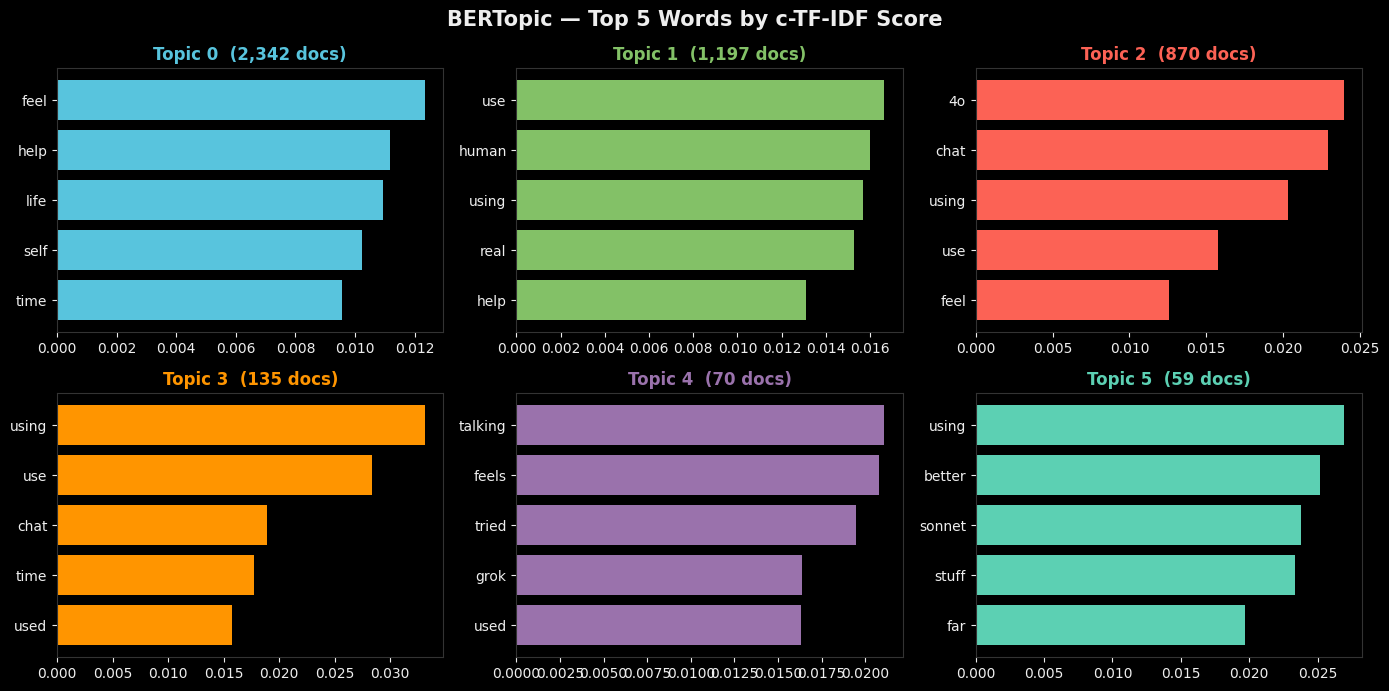

In [ ]:
# Bar chart: top 5 words for the first 6 topics
mpl.rcParams.update({'figure.facecolor': '#000000', 'axes.facecolor': '#000000',
                     'text.color': '#EEEEEE', 'axes.labelcolor': '#EEEEEE',
                     'xtick.color': '#EEEEEE', 'ytick.color': '#EEEEEE',
                     'axes.edgecolor': '#333333'})

COLORS = ['#58C4DD','#83C167','#FC6255','#FF9500','#9A72AC','#5CD0B3']
n_show = min(6, len(info_full[info_full['Topic'] != -1]))

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.patch.set_facecolor('#000000')
fig.suptitle('BERTopic — Top 5 Words by c-TF-IDF Score',
             color='#EEEEEE', fontsize=15, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.set_facecolor('#000000')
    if i >= n_show:
        ax.axis('off')
        continue
    topic_words = topic_model_full.get_topic(i)[:5]
    words, scores = zip(*topic_words)
    ax.barh(words[::-1], scores[::-1], color=COLORS[i], edgecolor='none')
    n_docs = info_full.loc[info_full['Topic'] == i, 'Count'].values[0]
    ax.set_title(f'Topic {i}  ({n_docs:,} docs)', color=COLORS[i],
                 fontsize=12, fontweight='bold')
    ax.tick_params(colors='#EEEEEE', labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

plt.tight_layout()
plt.show()

## 8. UMAP visualisation (2D projection for plotting only)
The 2D projection is *not* what HDBSCAN clustered — that used 5 dimensions.
This is purely a visualisation of the semantic neighbourhood structure.

Computing 2D UMAP projection for visualisation...


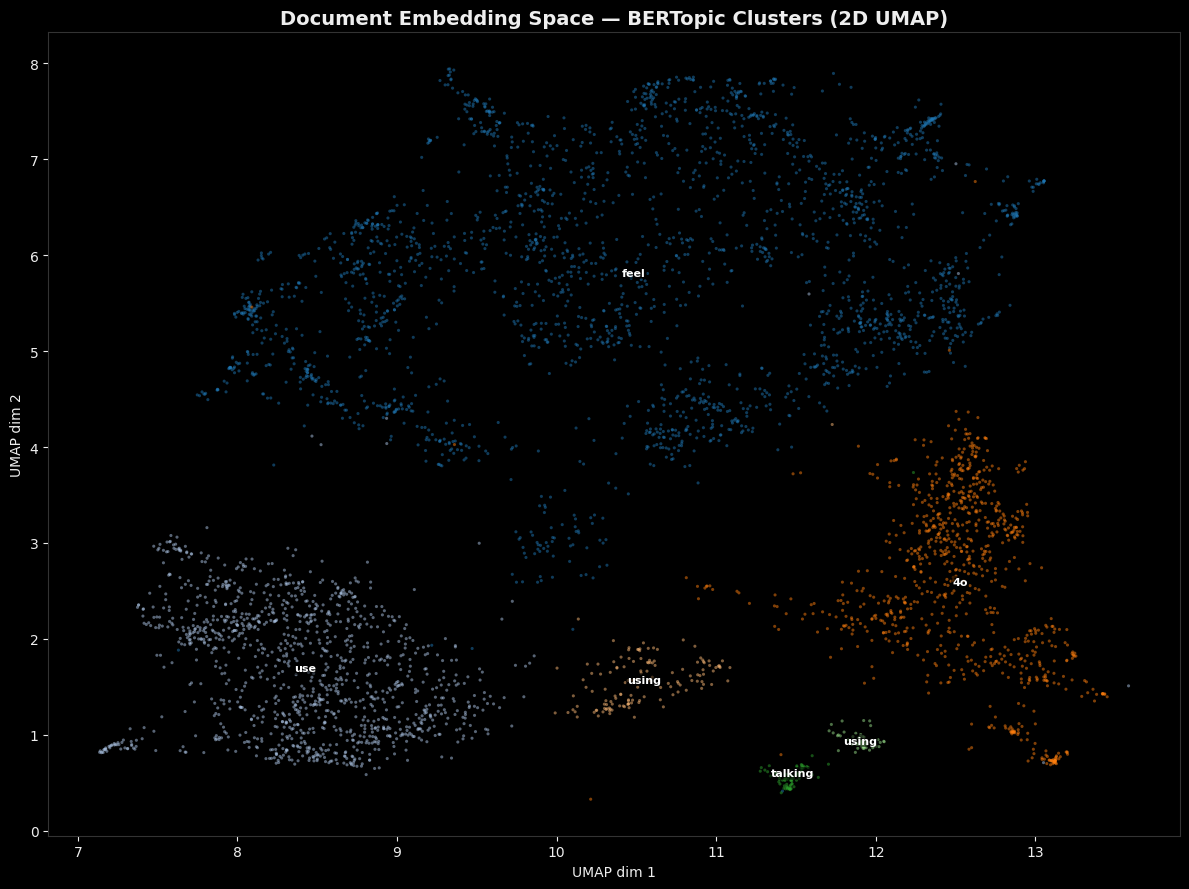

In [ ]:
print('Computing 2D UMAP projection for visualisation...')
umap_2d = UMAP(n_neighbors=15, n_components=2, min_dist=0.0,
               metric='cosine', random_state=42)
xy = umap_2d.fit_transform(embeddings)

df_plot = pd.DataFrame({'x': xy[:, 0], 'y': xy[:, 1], 'topic': topics_full})
df_plot = df_plot[df_plot['topic'] != -1]   # drop noise for clarity

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#000000')
ax.set_facecolor('#000000')

cmap = plt.get_cmap('tab20')
for tid in sorted(df_plot['topic'].unique())[:20]:   # cap at 20 for legibility
    mask = df_plot['topic'] == tid
    col  = cmap(tid % 20)
    ax.scatter(df_plot.loc[mask, 'x'], df_plot.loc[mask, 'y'],
               c=[col], s=5, alpha=0.5, edgecolors='none', label=f'T{tid}')
    # Label the cluster centroid
    cx = df_plot.loc[mask, 'x'].mean()
    cy = df_plot.loc[mask, 'y'].mean()
    top_word = topic_model_full.get_topic(tid)[0][0]
    ax.text(cx, cy, top_word, color='white', fontsize=8,
            ha='center', va='center', fontweight='bold',
            bbox=dict(facecolor='#000000', alpha=0.5, pad=1, edgecolor='none'))

ax.set_xlabel('UMAP dim 1')
ax.set_ylabel('UMAP dim 2')
ax.set_title('Document Embedding Space — BERTopic Clusters (2D UMAP)',
             color='#EEEEEE', fontsize=14, fontweight='bold')
ax.tick_params(colors='#EEEEEE')
plt.tight_layout()
plt.show()

In [ ]:
# ── Repräsentative Absätze pro Topic anzeigen ─────────────────────────────
for tid in sorted(set(topics_full)):
    if tid == -1:
        continue  # Noise überspringen

    top_words = ', '.join([w for w, _ in topic_model_full.get_topic(tid)[:6]])
    n_docs = info_full.loc[info_full['Topic'] == tid, 'Count'].values[0]

    print(f'\n{"="*80}')
    print(f'Topic {tid}  ({n_docs:,} Absätze)  —  Top-Wörter: {top_words}')
    print(f'{"="*80}')

    rep_docs = topic_model_full.get_representative_docs(tid)
    for i, doc in enumerate(rep_docs[:3], 1):
        preview = doc[:300] + ('...' if len(doc) > 300 else '')
        print(f'\n[{i}] {preview}')


Topic 0  (2,342 Absätze)  —  Top-Wörter: feel, help, life, self, time, emotional

[1] Phase 2: Strategic Trauma Mitigation & Self-Optimization Root Cause Identification. Trace each flaw or trauma back to its origin, identifying the earliest moments that formed these patterns.
Cognitive Reframing & Deprogramming - Develop new, healthier mental models to rewrite my internal narrative a...

[2] blah blah I’m crying all hard because he’s literally breaking my heart into a million pieces over and over again I keep on forgiving this man and it’s hard to leave this man alone because he’s my first everything literally first everything he keep on making them promises like he would never do this....

[3] ““It’s a cry from your nervous system to feel something” is exactly it. To be honest, the poppers don’t even have the effect on me that they’re supposed to have. I’m abusing them the way I abuse weed. I take hit after hit until my head hurts and I’m light headed and it kills my erection and the

## 9. Does topic distribution differ by subreddit?

In [ ]:
df['bertopic_topic_full'] = topics_full

# Zwei Gruppen bilden: Personal Story vs. der Rest
df['group'] = df['flair'].apply(lambda f: 'Personal Story' if f == 'Personal Story' else 'Rest (alle anderen Flairs)')

topic_share = (
    df[df['bertopic_topic_full'] != -1]
    .groupby(['group', 'bertopic_topic_full'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum(), axis=1)   # normalise to proportions
)

print('Themenverteilung: Personal Story vs. Rest (in %):')
print((topic_share * 100).round(1))
print()

# Topics mit dem größten Unterschied
gap = (topic_share.loc['Personal Story'] - topic_share.loc['Rest (alle anderen Flairs)']).abs()
top_diff_topics = gap.nlargest(6).index.tolist()

print('Topics mit dem größten Unterschied Personal Story vs. Rest:')
for tid in top_diff_topics:
    words = ', '.join([w for w, _ in topic_model_full.get_topic(tid)[:5]])
    ps  = topic_share.loc['Personal Story', tid]
    rest = topic_share.loc['Rest (alle anderen Flairs)', tid]
    print(f'  Topic {tid:2d} [{words}]')
    print(f'    Personal Story   {ps:.3f}   Rest   {rest:.3f}   Δ={ps-rest:+.3f}')

Themenverteilung: Personal Story vs. Rest (in %):
bertopic_topic_full            0     1     2    3    4    5
group                                                      
Personal Story              49.0  19.5  21.8  3.8  3.6  2.3
Rest (alle anderen Flairs)  50.2  26.2  18.3  2.8  1.3  1.2

Topics mit dem größten Unterschied Personal Story vs. Rest:
  Topic  1 [use, human, using, real, help]
    Personal Story   0.195   Rest   0.262   Δ=-0.067
  Topic  2 [4o, chat, using, use, feel]
    Personal Story   0.218   Rest   0.183   Δ=+0.035
  Topic  4 [talking, feels, tried, grok, used]
    Personal Story   0.036   Rest   0.013   Δ=+0.023
  Topic  0 [feel, help, life, self, time]
    Personal Story   0.490   Rest   0.502   Δ=-0.012
  Topic  5 [using, better, sonnet, stuff, far]
    Personal Story   0.023   Rest   0.012   Δ=+0.011
  Topic  3 [using, use, chat, time, used]
    Personal Story   0.038   Rest   0.028   Δ=+0.010


In [ ]:
# ── Schritt 10: Sundar Action-Route-Konstrukte im GESAMTEN Korpus ───────────
import re

# Gleiche Wortlisten wie im Personal-Story-Notebook, direkt aus Sundar (2020) abgeleitet
AGENCY_WORDS = ['control', 'choose', 'chose', 'choosing', 'decide', 'decided',
                'customize', 'customized', 'setting', 'settings']

COLLABORATION_WORDS = ['help', 'helped', 'helps', 'helpful', 'support', 'supported',
                        'together', 'assist', 'assisted', 'guide', 'guided']

AUGMENTATION_WORDS = ['suggest', 'suggested', 'suggestion', 'recommend', 'recommended',
                       'insight', 'perspective', 'idea', 'ideas']

TRUST_WORDS = ['trust', 'trusted', 'trusting', 'reliable', 'reliability',
               'honest', 'honestly', 'safe', 'safety', 'private', 'privacy',
               'judge', 'judged', 'judgment', 'understand', 'understood', 'understanding']

def count_matches(text, wordlist):
    text = str(text).lower()
    return sum(len(re.findall(rf'\b{re.escape(w)}\b', text)) for w in wordlist)

df['agency_count'] = df['paragraph_text'].apply(lambda t: count_matches(t, AGENCY_WORDS))
df['collaboration_count'] = df['paragraph_text'].apply(lambda t: count_matches(t, COLLABORATION_WORDS))
df['augmentation_count'] = df['paragraph_text'].apply(lambda t: count_matches(t, AUGMENTATION_WORDS))
df['trust_count'] = df['paragraph_text'].apply(lambda t: count_matches(t, TRUST_WORDS))

# ── Vergleich: Personal Story vs. Rest des Subreddits ────────────────────────
df['group'] = df['flair'].apply(lambda f: 'Personal Story' if f == 'Personal Story' else 'Rest (alle anderen Flairs)')

print('Anteil der Absätze mit mind. einem Treffer pro Sundar-Konstrukt:\n')
comparison = df.groupby('group')[
    ['agency_count', 'collaboration_count', 'augmentation_count', 'trust_count']
].apply(lambda g: (g > 0).mean())

print((comparison * 100).round(1).astype(str) + ' %')

print('\nDurchschnittliche Treffer pro Topic (gesamter Korpus):')
print(df[df['bertopic_topic_full'] != -1].groupby('bertopic_topic_full')[
    ['agency_count', 'collaboration_count', 'augmentation_count', 'trust_count']
].mean().round(2))

Anteil der Absätze mit mind. einem Treffer pro Sundar-Konstrukt:

                           agency_count collaboration_count  \
group                                                         
Personal Story                    4.1 %              24.2 %   
Rest (alle anderen Flairs)        4.1 %              22.5 %   

                           augmentation_count trust_count  
group                                                      
Personal Story                          4.6 %      17.3 %  
Rest (alle anderen Flairs)              5.9 %      15.7 %  

Durchschnittliche Treffer pro Topic (gesamter Korpus):
                     agency_count  collaboration_count  augmentation_count  \
bertopic_topic_full                                                          
0                            0.04                 0.27                0.05   
1                            0.05                 0.41                0.07   
2                            0.04                 0.32                0.0

## 10. Save outputs

In [ ]:
from pathlib import Path
OUTPUT_DIR = Path('/content/drive/MyDrive')

In [ ]:
OUT = OUTPUT_DIR   # euer Google-Drive-Ordner, damit es die Sitzung übersteht
OUT.mkdir(exist_ok=True)

# Vollständigen Korpus mit Topic-Zuordnung und Sundar-Konstrukt-Zählungen zusammenstellen
df['bertopic_topic_full'] = topics_full
df['topic_prob_full'] = [max(p) if hasattr(p, '__len__') else p for p in probs_full]

# Document-topic assignments (inkl. der Sundar-Konstrukt-Zählungen aus Schritt 10)
df[['post_id', 'paragraph_id', 'flair', 'bertopic_topic_full', 'topic_prob_full',
    'agency_count', 'collaboration_count', 'augmentation_count', 'trust_count']].to_parquet(
    OUT / 'bertopic_assignments_full.parquet', index=False
)

# Topic summary
topic_model_full.get_topic_info().to_csv(OUT / 'bertopic_topic_info_full.csv', index=False)

# Save the full model (includes embedder, UMAP, HDBSCAN)
topic_model_full.save(str(OUT / 'bertopic_full_model'),
                       serialization='safetensors', save_ctfidf=True,
                       save_embedding_model=False)   # embedding model is large; re-load from HF

print(f'Saved to {OUT}/')
print('  bertopic_assignments_full.parquet')
print('  bertopic_topic_info_full.csv')
print('  bertopic_full_model/')
print()
print('To reload the model later:')
print('  topic_model_full = BERTopic.load("' + str(OUT / "bertopic_full_model") + '",')
print('                                    embedding_model=embedding_model)')

2026-07-15 10:22:26,983 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Saved to /content/drive/MyDrive/
  bertopic_assignments_full.parquet
  bertopic_topic_info_full.csv
  bertopic_full_model/

To reload the model later:
  topic_model_full = BERTopic.load("/content/drive/MyDrive/bertopic_full_model",
                                    embedding_model=embedding_model)


## 11. Interactive visualisations (optional)
These open in a browser or Jupyter output cell.

In [ ]:
topic_model_full.visualize_topics()              # intertopic distance map
# topic_model_full.visualize_barchart(top_n_topics=12)
# topic_model_full.visualize_heatmap()             # topic similarity matrix
# topic_model_full.visualize_documents(docs, embeddings=embeddings, hide_document_hover=True)